In [1]:
import random

class RoomNode:
    def __init__(self, room_type, level, id):
        """
        room_type: "start", "must", "end", 或 "reward"
        level: 节点所在的层级（根为 0）
        id: 唯一标识符
        """
        self.room_type = room_type
        self.level = level
        self.children = []  # 最多 3 个子节点
        self.id = id
        self.w = random.randint(3, 6)
        self.h = random.randint(3, 6)

    def __repr__(self):
        return f"RoomNode(id={self.id}, type={self.room_type}, level={self.level}, children={len(self.children)})"

def count_reward_descendants(node):
    """
    递归统计该节点所有后代中（包括直接和间接）的奖励房间数量
    """
    count = 0
    for child in node.children:
        if child.room_type == "reward":
            count += 1
            count += count_reward_descendants(child)
    return count

def generate_roguelike_tree( num_must, num_reward):
    """
    生成一棵满足以下定义的三叉树：
      - 开始房间（start）：树的根节点，数量必须为 1。
      - 终点房间（end）：主路径上最深的节点，数量必须为 1。
      - 必经房间（must）：主路径上除开始和终点以外的节点，主路径总节点数由 num_must 指定（至少 2）。
      - 奖励房间（reward）：除主路径外的其他房间，总数由 num_reward 指定，
          且任一奖励房间的所有递归子房间数量不超过 2。
    """
    assert num_must >= 2, "主路径节点数至少为 2（包含开始和终点）"
    
    id_counter = 1
    main_branch = []

    # 创建主路径：开始房间（根节点）、必经房间和终点房间
    start_node = RoomNode("start", level=0, id=id_counter)
    id_counter += 1
    main_branch.append(start_node)
    
    for lvl in range(1, num_must - 1):
        node = RoomNode("must", level=lvl, id=id_counter)
        id_counter += 1
        main_branch.append(node)
    
    end_node = RoomNode("end", level=num_must - 1, id=id_counter)
    id_counter += 1
    main_branch.append(end_node)
    
    # 按顺序连接主路径节点：每个节点的第一个子节点是主路径下一个节点
    for i in range(len(main_branch) - 1):
        main_branch[i].children.append(main_branch[i + 1])
    
    # 将主路径上的所有节点收集到列表中，便于后续添加奖励房间
    all_nodes = list(main_branch)
    
    # 添加奖励房间：只在满足以下条件的节点上添加奖励房间
    # 1. 节点层级小于终点房间的层级（不允许延伸到主路径之后）
    # 2. 节点不是终点房间
    # 3. 节点的直接子节点数量不足 3
    # 4. 如果节点为奖励房间，则其所有递归后代奖励房间数量 < 2
    rewards_to_add = num_reward
    while rewards_to_add > 0:
        eligible_nodes = []
        for node in all_nodes:
            if node.level < (num_must - 1) and node.room_type != "end" and len(node.children) < 3:
                if node.room_type == "reward":
                    if count_reward_descendants(node) < 2:
                        eligible_nodes.append(node)
                else:
                    eligible_nodes.append(node)
        if not eligible_nodes:
            break  # 没有合适的节点添加奖励房间
        parent = random.choice(eligible_nodes)
        reward_node = RoomNode("reward", level=parent.level + 1, id=id_counter)
        id_counter += 1
        parent.children.append(reward_node)
        all_nodes.append(reward_node)
        rewards_to_add -= 1

    return start_node
    
def build_room_children_map(root):
    """
    参数:
      root: 房间节点，假设具有属性 id 和 children（列表）
    返回:
      一个字典，键为每个房间的 id，值为该房间直接子节点 id 的列表
    """
    room_map = {}

    def traverse(node):
        # 记录当前节点及其直接子节点的 id
        room_map[node.id] = [child.id for child in node.children]
        # 遍历所有子节点
        for child in node.children:
            traverse(child)
    
    traverse(root)
    return room_map
    
def build_room_node_dict(root):
    """
    参数:
      root: 房间节点，假定具有属性 id 和 children（列表）
    返回:
      一个字典，键为每个房间的 id，值为对应的房间节点对象
    """
    node_dict = {}
    
    def traverse(node):
        node_dict[node.id] = node
        for child in node.children:
            traverse(child)
    
    traverse(root)
    return node_dict

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

def hierarchy_pos(G, root, width=20.0, vert_gap=0.2, vert_loc=0, xcenter=0.5):
    """
    为树图生成一个层次布局。
    
    参数:
      G: 一个网络图（必须是树状图）
      root: 根节点的标识符
      width: 布局总宽度
      vert_gap: 各层之间的垂直间距
      vert_loc: 根节点的垂直位置
      xcenter: 根节点的水平位置
      
    返回:
      pos: 一个字典，key 为节点标识，value 为 (x, y) 坐标
    """
    pos = {root: (xcenter, vert_loc)}
    children = list(G.successors(root))
    if children:
        dx = width / len(children)
        nextx = xcenter - width/2 - dx/2
        for child in children:
            nextx += dx
            pos.update(hierarchy_pos(G, child, width=dx, vert_gap=vert_gap,
                                       vert_loc=vert_loc - vert_gap, xcenter=nextx))
    return pos

def draw_tree(root):
    """
    接收一个三叉树根节点，然后绘制出树的图像。假定每个节点具有属性:
      - id: 唯一标识符
      - room_type: 节点类型（例如 "start", "must", "end", "reward"）
      - children: 子节点列表
    """
    G = nx.DiGraph()
    
    # 递归构建网络图
    def add_nodes_edges(node):
        # 用节点 id 作为图中节点的标识，同时添加标签
        G.add_node(node.id, label=f"{node.room_type}\n({node.id})")
        for child in node.children:
            G.add_edge(node.id, child.id)
            add_nodes_edges(child)
    
    add_nodes_edges(root)
    
    # 获取层次布局的位置
    pos = hierarchy_pos(G, root.id)
    labels = nx.get_node_attributes(G, 'label')
    
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, labels=labels, node_size=100,
            node_color="skyblue", arrows=True, arrowstyle='->', arrowsize=15)
    plt.title("三叉树结构图")
    plt.axis('off')
    plt.show()


In [3]:
import random

def layout_rooms(root):
    """
    以 root 为参数，对树结构进行房间布局。每个节点将被放置在网格中，
    要求：
      - 每个房间只占据一个网格，房间之间不重叠。
      - 相连的房间在网格上必须邻接（上下左右）。
      - 房间布局尽量紧凑，以 root 房间为中心，使得所有房间离 (0,0) 尽量近。
    此外，布局过程中在可选位置中引入随机性：可选位置根据其曼哈顿距离 (到 (0,0)) 的倒数作为权重进行随机选择。
    返回一个二维数组，每个单元格存放形如 "room_type-id" 的字符串，没有房间的格子用 None 表示。
    """
    # pos_dict：记录每个节点（按 id）在网格中的坐标 (x, y)
    pos_dict = {}
    # occupied：记录哪些坐标已经被使用，映射 (x, y) -> 对应节点
    occupied = {}
    
    def neighbors(coord):
        """返回一个坐标上下左右四个邻居"""
        x, y = coord
        return [(x, y-1), (x, y+1), (x-1, y), (x+1, y)]
    
    def manhattan(coord):
        """计算坐标到 (0,0) 的曼哈顿距离"""
        x, y = coord
        return abs(x) + abs(y)
    
    def dfs(node, parent_coord=None, grandparent_coord=None):
        # 如果没有父节点，则为根房间，固定在 (0,0)
        if parent_coord is None:
            pos_dict[node.id] = (0, 0)
            occupied[(0, 0)] = node
        current_coord = pos_dict[node.id]
        for child in node.children:
            cand = neighbors(current_coord)
            # 排除父节点来源方向，防止回退
            if grandparent_coord is not None and grandparent_coord in cand:
                cand.remove(grandparent_coord)
            # 过滤掉已占用的坐标
            available = [p for p in cand if p not in occupied]
            if not available:
                raise Exception(f"无法为节点 {child.id} 分配坐标，检查树结构和布局规则。")
            # 根据曼哈顿距离加权随机选择
            # 距离越近，权重越大（权重 = 1 / (曼哈顿距离 + 1)）
            weights = [1.0 / (manhattan(p) + 1) for p in available]
            chosen = random.choices(available, weights=weights, k=1)[0]
            pos_dict[child.id] = chosen
            occupied[chosen] = child
            dfs(child, parent_coord=chosen, grandparent_coord=current_coord)
    
    dfs(root)
    
    # 计算所有房间所占用坐标的边界
    xs = [coord[0] for coord in pos_dict.values()]
    ys = [coord[1] for coord in pos_dict.values()]
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)
    width = max_x - min_x + 1
    height = max_y - min_y + 1
    
    # 根据计算的边界生成二维数组，空格填充 -1
    grid = [[-1 for _ in range(width)] for _ in range(height)]
    for node_id, (x, y) in pos_dict.items():
        grid_y = y - min_y  # 行号
        grid_x = x - min_x  # 列号
        # 这里用 "room_type-id" 表示房间
        node = occupied[(x, y)]
        grid[grid_y][grid_x] = node.id
    
    return grid

# 辅助函数：打印二维数组布局
def print_grid(grid):
    for row in grid:
        print(" ".join(cell if cell is not None else "----" for cell in row))




In [4]:
def layout_rooms_backtracking_best(root):
    """
    使用回溯搜索为树生成一个最紧凑的布局（所有房间到 (0,0) 的最大曼哈顿距离最小）。
    要求：
      - 根节点固定在 (0,0)；
      - 每个节点必须放在其父节点的上下左右邻居之一，且不能重叠；
    如果存在合法布局，则返回一个二维数组（最小尺寸），每个单元格为 "room_type-id" 的字符串；
    如果搜索不到，则返回 None。
    """
    # 1. 预处理：前序遍历，构建节点列表和父节点映射
    pre_order = []
    parent_map = {}  # 记录 node.id -> parent.id
    def dfs_tree(node, parent=None):
        pre_order.append(node)
        if parent is not None:
            parent_map[node.id] = parent.id
        for child in node.children:
            dfs_tree(child, node)
    dfs_tree(root)
    
    total_nodes = len(pre_order)
    
    # 2. 回溯搜索
    assigned = {}    # node.id -> (x, y)
    occupied = set() # 集合存储已使用的坐标
    
    # 固定根节点在 (0,0)
    assigned[root.id] = (0, 0)
    occupied.add((0, 0))
    
    best_layout = None
    best_score = float('inf')
    
    def manhattan(coord):
        x, y = coord
        return abs(x) + abs(y)
    
    def neighbors(coord):
        x, y = coord
        return [(x, y-1), (x, y+1), (x-1, y), (x+1, y)]
    
    # 递归回溯，从 pre_order[1] 开始为每个节点分配位置
    def dfs(index):
        nonlocal best_layout, best_score
        if index == total_nodes:
            # 完整分配，计算当前布局的最大曼哈顿距离
            current_score = max(manhattan(pos) for pos in assigned.values())
            if current_score < best_score:
                best_score = current_score
                best_layout = assigned.copy()
            return
        node = pre_order[index]
        # 每个节点的候选位置必须是其父节点的邻居
        parent_id = parent_map[node.id]
        parent_coord = assigned[parent_id]
        cand = neighbors(parent_coord)
        # 候选位置按到 (0,0) 的曼哈顿距离排序（越近优先）
        cand.sort(key=manhattan)
        for pos in cand:
            if pos in occupied:
                continue
            # 分配位置
            assigned[node.id] = pos
            occupied.add(pos)
            dfs(index + 1)
            # 回溯
            del assigned[node.id]
            occupied.remove(pos)
    
    dfs(1)
    
    if best_layout is None:
        return None  # 表示无法布局
    
    # 3. 根据 best_layout 构造最小尺寸二维数组
    xs = [pos[0] for pos in best_layout.values()]
    ys = [pos[1] for pos in best_layout.values()]
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)
    width = max_x - min_x + 1
    height = max_y - min_y + 1
    
    # 构造节点字典便于查找（node.id -> node）
    node_dict = {}
    def traverse_nodes(node):
        node_dict[node.id] = node
        for child in node.children:
            traverse_nodes(child)
    traverse_nodes(root)
    
    grid = [[-1 for _ in range(width)] for _ in range(height)]
    for node_id, (x, y) in best_layout.items():
        grid_y = y - min_y
        grid_x = x - min_x
        grid[grid_y][grid_x] = node_id
    return grid


In [5]:
import heapq
import random


class LayoutState:
    def __init__(self, assigned, occupied, depth, root_coord=(0, 0)):
        # assigned: 字典，记录 node.id -> (x, y)
        # occupied: 集合，存储已占用的坐标
        # depth: 当前已分配节点数
        self.assigned = assigned
        self.occupied = occupied
        self.depth = depth
        self.root_coord = root_coord
    def __lt__(self, other):
        return self.get_f_score() < other.get_f_score()
    def __hash__(self):
        return hash((frozenset(self.assigned.items()), frozenset(self.occupied), self.depth))
    def __eq__(self, other):
        return (self.depth == other.depth and 
                self.assigned == other.assigned and 
                self.occupied == other.occupied)
    def get_f_score(self):
        # f = g + h，其中 g 为当前深度，h 为启发式函数值
        g = self.depth
        h = self.get_heuristic()
        return g + h
    def get_heuristic(self):
        # 启发式：所有已分配房间到根 (0,0) 的曼哈顿距离之和
        total = 0
        for coord in self.assigned.values():
            total += abs(coord[0]) + abs(coord[1])
        return total

def get_adjacent_positions(pos):
    """返回 pos 的上下左右四个邻居坐标"""
    x, y = pos
    return [(x, y-1), (x, y+1), (x-1, y), (x+1, y)]

def calc_node_count(root):
    """递归计算树中节点总数"""
    count = 1
    for child in root.children:
        count += calc_node_count(child)
    return count

def construct_parent_mapping(root):
    """构造父节点映射，返回字典 child.id -> parent.id"""
    mapping = {}
    def dfs(node, parent=None):
        for child in node.children:
            mapping[child.id] = node.id
            dfs(child, node)
    dfs(root)
    return mapping

def preorder_traversal(root):
    """前序遍历树，返回节点列表"""
    result = []
    def dfs(node):
        result.append(node)
        for child in node.children:
            dfs(child)
    dfs(root)
    return result

def select_next_node(root, depth):
    """
    按前序遍历顺序返回下一个需要分配位置的节点。
    假设根节点已分配，depth 从 1 开始。
    """
    pre_list = preorder_traversal(root)
    return pre_list[depth]

def create_node_dictionary(root):
    """构造节点字典，返回 {node.id: node}"""
    d = {root.id: root}
    for child in root.children:
        d.update(create_node_dictionary(child))
    return d

def convert_assigned_to_grid(assigned, node_dict):
    """根据 assigned 将节点分布转换为最小尺寸二维数组，每个单元显示 'room_type-id'"""
    xs = [pos[0] for pos in assigned.values()]
    ys = [pos[1] for pos in assigned.values()]
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)
    width = max_x - min_x + 1
    height = max_y - min_y + 1
    grid = [[-1 for _ in range(width)] for _ in range(height)]
    for node_id, (x, y) in assigned.items():
        grid_y = y - min_y
        grid_x = x - min_x
        grid[grid_y][grid_x] = node_id
    return grid

def a_star_search_with_randomness(root):
    """
    使用 A* 启发式搜索为房间树生成紧凑布局，并在候选位置排序中加入随机因素。
    条件：
      - 根节点固定在 (0,0)；
      - 每个节点必须放在其父节点的上下左右邻近位置中，且不重叠。
    如果找到合法布局，则返回一个二维数组（每个单元为 "room_type-id" 的字符串），否则返回 None。
    """
    total = calc_node_count(root)
    parent_map = construct_parent_mapping(root)
    initial_state = LayoutState(assigned={root.id: (0, 0)}, occupied={(0, 0)}, depth=1)
    open_list = []
    closed_set = set()
    heapq.heappush(open_list, initial_state)
    
    best_assigned = -1
    while open_list:
        current_state = heapq.heappop(open_list)
        if current_state.depth == total:
            best_assigned = current_state.assigned
            break
        # 按前序遍历顺序获取下一个待分配节点（depth 从 1 开始）
        cur_node = select_next_node(root, current_state.depth)
        # 取该节点父节点的坐标
        parent_coord = current_state.assigned[parent_map[cur_node.id]]
        # 获取父节点相邻位置，并按 (曼哈顿距离, 随机因子) 排序
        candidates = get_adjacent_positions(parent_coord)
        candidates = sorted(candidates, key=lambda p: (abs(p[0]) + abs(p[1]), random.random()))
        for pos in candidates:
            if pos in current_state.occupied:
                continue
            new_assigned = current_state.assigned.copy()
            new_assigned[cur_node.id] = pos
            new_occupied = current_state.occupied.copy()
            new_occupied.add(pos)
            new_state = LayoutState(new_assigned, new_occupied, current_state.depth + 1)
            if new_state not in closed_set:
                heapq.heappush(open_list, new_state)
                closed_set.add(new_state)
    if best_assigned is None:
        return None
    # 将最佳 assigned 转换为二维数组后返回
    node_dict = create_node_dictionary(root)
    grid = convert_assigned_to_grid(best_assigned, node_dict)
    return grid

def print_grid(grid):
    """打印二维数组布局"""
    if grid is None:
        print("没有找到合法布局。")
        return
    for row in grid:
        print(row)



In [6]:
def fill_walls_in_map_eight_directions(MAP, x):
    """
    参数:
      MAP: 二维数组，每个元素为数字
      x: 用于填充墙壁的数字
    功能:
      对于每个单元格，如果它的值为 -1 且在其八个方向（上下左右及四个对角）中至少有一个邻居的值 >= 0，
      则认为该单元格为墙壁，将其替换为 x。返回一个新的二维数组，不修改原始 MAP。
    """
    # 生成 MAP 的深拷贝
    new_map = [[i for i in row] for row in MAP]
    rows = len(new_map)
    if rows == 0:
        return new_map
    cols = len(new_map[0])
    
    # 定义八个方向的偏移量
    directions = [(-1, -1), (-1, 0), (-1, 1),
                  (0, -1),           (0, 1),
                  (1, -1),  (1, 0),  (1, 1)]
    
    for i in range(rows):
        for j in range(cols):
            if MAP[i][j] == -1:
                is_wall = False
                for di, dj in directions:
                    ni, nj = i + di, j + dj
                    if 0 <= ni < rows and 0 <= nj < cols:
                        if MAP[ni][nj] >= 0:
                            is_wall = True
                            break
                if is_wall:
                    new_map[i][j] = x
    return new_map


In [7]:
def generate_rect_map(block_w, block_h, rect_w, rect_h, idx = 0):
    """
    生成一个二维数组，尺寸为 block_h x block_w，表示地图，
    数组中包含一个由 1 组成的随机长方形（或正方形）区域，其尺寸至少为 min_w x min_h，
    长方形随机放置在地图中，其余区域为 0。
    
    参数:
      block_w: 地图的宽度（列数）
      block_h: 地图的高度（行数）
      min_w: 长方形最小宽度
      min_h: 长方形最小高度
      
    返回:
      grid: 二维列表，grid[i][j] 为 >= 0 表示该格为地面，-1 表示阻挡
    """
    
    # 创建一个全为 -1 的二维数组
    grid = [[-1 for _ in range(block_w)] for _ in range(block_h)]

    
    # 随机选取矩形的左上角位置，使得整个矩形可以放入地图内
    max_left = block_w - rect_w - 1
    max_top = block_h - rect_h - 1
    left = random.randint(1, max_left)
    top = random.randint(1, max_top)
    
    # 填充矩形区域为 1
    for i in range(top, top + rect_h):
        for j in range(left, left + rect_w):
            grid[i][j] = idx
    
    return grid

In [8]:
def merge_rooms_into_map(GlobalMap):
    """
    将 GlobalMap 中的各个房间合并成一个巨大的地图。
    
    参数:
      GlobalMap: 一个二维数组，其中每个元素 room 都是一个二维数组（数字矩阵）。
                 假设 GlobalMap 为 m x n 的结构，每个 room 的尺寸为 room_h x room_w，
                 同一行内的 room 尺寸一致，不同行建议也一致。
    
    返回:
      merged_map: 合并后的巨大地图，为一个二维数组，
                  其中房间按 GlobalMap 中的排列方式拼接在一起。
    """
    merged_map = []
    
    # 遍历 GlobalMap 的每一行（每一行是一组房间）
    for room_row in GlobalMap:
        # 假设该行至少有一个房间，取第一个房间的行数
        room_h = len(room_row[0])
        # 对于当前行的每个房间，要求它们的行数一致
        # 对于 room_row 中每一行索引 i，构造一整行的地图数据
        for i in range(room_h):
            merged_line = []
            for room in room_row:
                # room[i] 为当前房间的第 i 行
                merged_line.extend(room[i])
            merged_map.append(merged_line)
    return merged_map


In [9]:
from collections import deque
import copy

def bfs_find_path(map_grid, source_coords, target_coords):
    """
    从 source_coords（多个起点）出发，在 map_grid 中寻找到 target_coords 中任一目标的最短路径。
    允许所有单元通过（只判断边界），返回的路径为从起点到目标的一系列 (row, col) 坐标。
    如果找不到，返回 None。
    """
    rows = len(map_grid)
    cols = len(map_grid[0]) if rows > 0 else 0
    q = deque()
    pred = {}  # 前驱字典：key 为 (r, c)，value 为上一个 (r, c)
    visited = set()
    
    for s in source_coords:
        q.append(s)
        visited.add(s)
    
    found = None
    while q:
        cur = q.popleft()
        if cur in target_coords:
            found = cur
            break
        r, c = cur
        if(map_grid[r][c]!=-1 and cur not in source_coords and cur not in target_coords):continue
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < rows and 0 <= nc < cols:
                if (nr, nc) not in visited:
                    visited.add((nr, nc))
                    pred[(nr, nc)] = cur
                    q.append((nr, nc))
    if found is None:
        return None
    # 重构路径，从 found 回溯到起点
    path = []
    cur = found
    while cur not in source_coords:
        path.append(cur)
        cur = pred[cur]
    path.append(cur)
    path.reverse()
    return path

def connect_rooms_on_map(MAP, start, target_list):
    """
    参数:
      MAP: 二维数组，每个元素为数字，其中 -1 表示阻挡，其它正数代表各个房间（例如 8 表示出发房间）
      start: 出发房间编号（例如 8）
      target_list: 目标房间编号列表（例如 [4,6]）
    
    功能:
      对于 target_list 中的每个目标房间，执行如下步骤：
        1. 在 MAP 中找到所有出发单元（值为 start）作为起点，
           以及所有目标单元（值为目标编号）作为目标集合。
        2. 使用 BFS 找到最短路径（允许经过任何单元，只判断边界）。
        3. 沿着路径（除目标单元外），仅对原值为 -1 的单元进行“凿通”：将其值设置为 start，
           表示用出发房间填充，从而形成通路。
        4. 更新 MAP，再对下一个目标房间执行相同操作。
    返回:
      修改后的二维数组 MAP。
    """
    # 复制 MAP，避免直接修改原数据（也可以原地修改）
    grid = copy.deepcopy(MAP)
    rows = len(grid)
    cols = len(grid[0]) if rows > 0 else 0
    
    for target in target_list:
        # 收集所有出发单元：值等于 start
        source_coords = [(r, c) for r in range(rows) for c in range(cols) if grid[r][c] == start]
        # 收集所有目标单元：值等于 target
        target_coords = {(r, c) for r in range(rows) for c in range(cols) if grid[r][c] == target}
        
        if not source_coords or not target_coords:
            # 若没有出发单元或目标单元，则无法连接，跳过该目标
            continue
        
        # 寻找从任一出发单元到任一目标单元的最短路径
        path = bfs_find_path(grid, source_coords, target_coords)
        if path is None:
            # 没有找到路径，跳过
            continue
        
        # 沿着路径（除最后一个目标单元），对原值为 -1 的单元进行凿通，将其设置为 start
        # 注意：这里不改变起点（本身就是 start）和目标单元
        for cell in path[:-1]:
            r, c = cell
            if grid[r][c] == -1:
                grid[r][c] = 0
    return grid


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import random

def draw_map(grid):
    """
    参数:
      grid: 二维数组，每个元素为数字
            -1 表示阻挡（绘制为黑色）
            99 表示特殊区域（绘制为棕色）
            其他数字：为相同的数字分配同一种随机颜色
    功能:
      绘制一个图像，每个数字对应一个小方块，所有小方块拼接成整块图像。
    """
    rows = len(grid)
    cols = len(grid[0]) if rows > 0 else 0
    
    # 构造一个颜色映射：key 为数字，value 为 RGB 颜色（0-1）
    color_map = {}
    # 预定义：-1 为黑色，99 为棕色（这里采用一种棕色调）
    color_map[-1] = (0, 0, 0)
    color_map[99] = (165/255, 42/255, 42/255)  # 棕色
    
    # 遍历 grid 中的其他数字，分配随机颜色（同一个数字保持一致）
    for r in range(rows):
        for c in range(cols):
            val = grid[r][c]
            if val not in color_map:
                # 为其他数字随机生成 RGB 颜色
                # 随机颜色取值范围 [0, 1]
                color_map[val] = (random.random(), random.random(), random.random())
    
    # 构造图像数组，形状为 (rows, cols, 3)
    img = np.zeros((rows, cols, 3))
    for r in range(rows):
        for c in range(cols):
            img[r, c, :] = color_map[grid[r][c]]
    
    plt.figure(figsize=(cols/2, rows/2))
    plt.imshow(img, interpolation='none')
    plt.axis('off')
    plt.show()



In [11]:
def generate_global_unlinked_map(tree_root):
    grid = a_star_search_with_randomness(tree_root)
    room_dic = build_room_node_dict(tree_root)
    blockSize = 0
    for room in room_dic.values():
        blockSize = max(blockSize, max(room.w,room.h) + 2)
    globalMap = []
    for raw in grid:
        tmp = []
        for i in raw:
            if i < 0:
                tmp.append([[-1 for _ in range(blockSize)] for _ in range(blockSize)])
            else:
                tmp.append(generate_rect_map(blockSize, blockSize, room_dic[i].w, room_dic[i].h, i))
        globalMap.append(tmp)
    
    return merge_rooms_into_map(globalMap)

In [12]:
def generat_final_map(tree_root):
    global_map = generate_global_unlinked_map(tree_root)
    room_map = build_room_children_map(tree_root)
    for room_id in room_map.keys():
        global_map = connect_rooms_on_map(global_map,room_id,room_map[room_id])
    return fill_walls_in_map_eight_directions(global_map,99)

In [13]:
# 示例：设置随机种子后生成一棵树
random.seed(84)

D:\ANACONDA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\ANACONDA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\ANACONDA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26641 (\N{CJK UNIFIED IDEOGRAPH-6811}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\ANACONDA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\ANACONDA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26500 (\N{CJK UNIFIED IDEOGRAPH-6784}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\ANACONDA\Lib\site

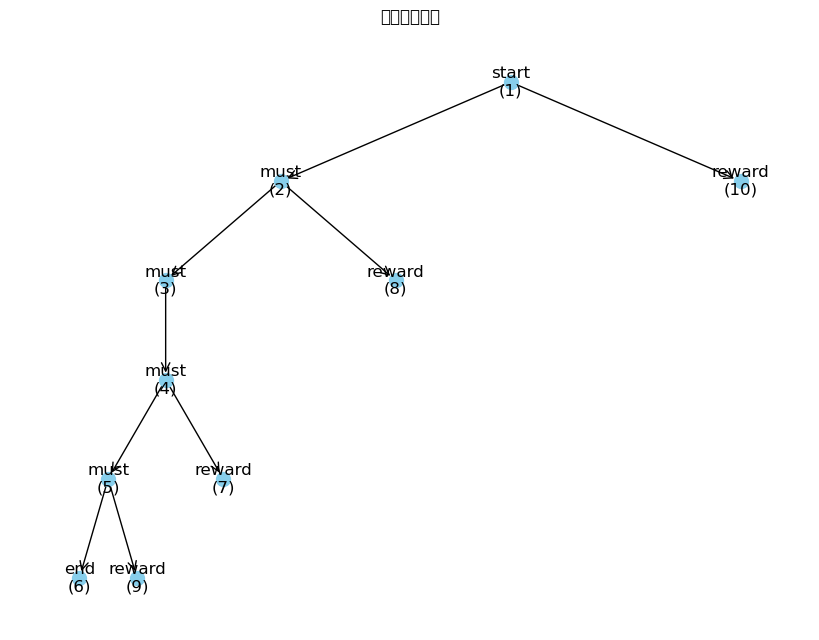

In [14]:

tree_root = generate_roguelike_tree(num_must=6, num_reward=4)
draw_tree(tree_root)

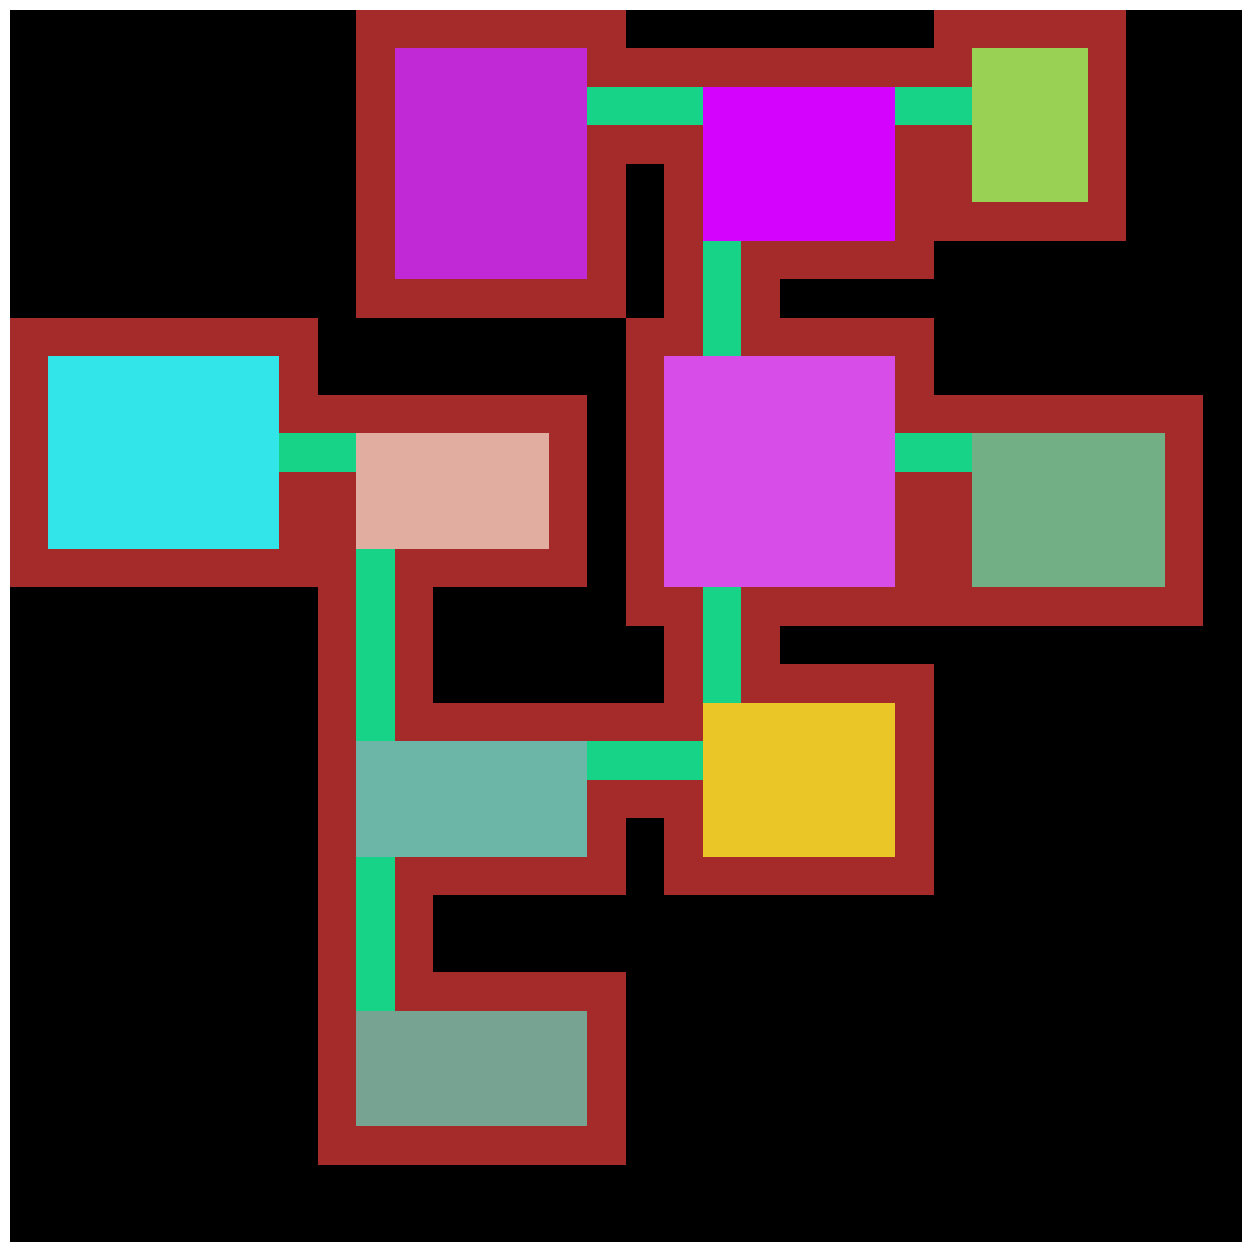

In [20]:
final_map = generat_final_map(tree_root)
draw_map(final_map)

In [21]:
from flask import Flask, jsonify

app = Flask(__name__)

@app.route('/world', methods=['GET'])
def get_map():
    """
    GET /world 返回 MAP 的 JSON 表示
    """
    print("ok")
    tree_root = generate_roguelike_tree(num_must=6, num_reward=4)
    final_map = generat_final_map(tree_root)
    draw_map(final_map)
    return jsonify(final_map)

if __name__ == '__main__':
    # 监听所有网卡，端口 5000
    app.run(host='0.0.0.0', port=8001)


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8001
 * Running on http://192.168.1.43:8001
Press CTRL+C to quit
192.168.1.43 - - [29/Mar/2025 11:52:51] "GET /world HTTP/1.1" 200 -


ok


192.168.1.43 - - [29/Mar/2025 11:52:57] "GET /world HTTP/1.1" 200 -
192.168.1.43 - - [29/Mar/2025 11:52:57] "GET /world HTTP/1.1" 200 -
192.168.1.43 - - [29/Mar/2025 11:52:57] "GET /world HTTP/1.1" 200 -
192.168.1.43 - - [29/Mar/2025 11:52:57] "GET /world HTTP/1.1" 200 -
192.168.1.43 - - [29/Mar/2025 11:52:57] "GET /world HTTP/1.1" 200 -


ok
ok
ok
ok
ok


...

ok


192.168.1.43 - - [29/Mar/2025 14:15:13] "GET /world HTTP/1.1" 200 -


ok


192.168.1.43 - - [29/Mar/2025 14:18:09] "GET /world HTTP/1.1" 200 -


ok
